<a href="https://colab.research.google.com/github/tong0208/trade_diversion_data/blob/main/Trade_Diversion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
if not os.path.exists('/content/trade_diversion_data'):
    print("Downloading data from GitHub...")
    !git clone https://github.com/tong0208/trade_diversion_data.git
else:
    print("Data folder already exists.")

# Load and clean data
def clean_trade_data(df):
    df = df.dropna()
    year_cols = [col for col in df.columns if str(col).isdigit()]
    if year_cols:
        df = df[(df[year_cols] != 0).any(axis=1)]
    return df

path = '/content/trade_diversion_data/'

# Country-level data
US_import_value = clean_trade_data(pd.read_excel(os.path.join(path, 'U.S. import value by country.xlsx')))
US_import_share = clean_trade_data(pd.read_excel(os.path.join(path, 'Share of U.S. imports by country.xlsx')))
CHN_export_value = clean_trade_data(pd.read_excel(os.path.join(path, 'China export value by country.xlsx')))
CHN_export_share = clean_trade_data(pd.read_excel(os.path.join(path, 'Share of China exports by country.xlsx')))

# Product-level values
prod_Canada_val = clean_trade_data(pd.read_excel(os.path.join(path, 'US import value - Canada (by sector).xlsx')))
prod_China_val = clean_trade_data(pd.read_excel(os.path.join(path, 'US import value - China (by sector).xlsx')))
prod_Mexico_val = clean_trade_data(pd.read_excel(os.path.join(path, 'US import value - Mexico (by sector).xlsx')))
prod_Vietnam_val = clean_trade_data(pd.read_excel(os.path.join(path, 'US import value - Vietnam (by sector).xlsx')))

# Product-level shares
prod_CAN_share = clean_trade_data(pd.read_excel(os.path.join(path, 'US import share - Canada (by prod).xlsx')))
prod_CHN_share = clean_trade_data(pd.read_excel(os.path.join(path, 'US import share - China (by prod).xlsx')))
prod_MEX_share = clean_trade_data(pd.read_excel(os.path.join(path, 'US import share - Mexico (by prod).xlsx')))
prod_VIET_share = clean_trade_data(pd.read_excel(os.path.join(path, 'US import share - Vietnam (by prod).xlsx')))

# Tariffs and GDP
US_tariffs = clean_trade_data(pd.read_excel(os.path.join(path, 'US weighted average tariffs by countries.xlsx')))
tariffs_chinese_prod = clean_trade_data(pd.read_excel(os.path.join(path, 'Weighted average tariffs on chinese prod.xlsx')))
GDP = clean_trade_data(pd.read_excel(os.path.join(path, 'Country GDP.xls')))
income_class = pd.read_excel(os.path.join(path, 'Country GDP.xls'), sheet_name='Metadata - Countries')

Cloning into 'trade_diversion_data'...
remote: Enumerating objects: 37, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 37 (delta 19), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (37/37), 407.21 KiB | 7.54 MiB/s, done.
Resolving deltas: 100% (19/19), done.


In [ ]:
name_corrections = {
    'United States': 'United States of America',
    'Korea, Rep.': 'South Korea',
    'Russian Federation': 'Russia',
    'Viet Nam': 'Vietnam'
}

US_import_share['Partner Name'] = US_import_share['Partner Name'].replace(name_corrections)
US_import_value['Partner Name'] = US_import_value['Partner Name'].replace(name_corrections)

#  US import share by partner

pre_years = [str(y) for y in range(2012, 2018)]
post_years = [str(y) for y in range(2018, 2023)]

year_cols = [str(y) for y in range(2012, 2023)]

eu_members = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark',
    'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland',
    'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands',
    'Poland', 'Portugal', 'Romania', 'Slovak Republic', 'Slovenia', 'Spain', 'Sweden'
]

region_map = {
    'United States': 'USA',
    'Vietnam': 'ASEAN', 'Thailand': 'ASEAN', 'Malaysia': 'ASEAN',
    'Singapore': 'ASEAN', 'Philippines': 'ASEAN','Indonesia': 'ASEAN',
    'Germany': 'EU', 'France': 'EU', 'Italy': 'EU', 'Spain': 'EU', 'Netherlands': 'EU',
    'South Africa': 'Africa', 'Nigeria': 'Africa', 'Egypt': 'Africa',
    'Mexico': 'LatAm', 'Brazil': 'LatAm', 'Argentina': 'LatAm'
}

In [ ]:
tariffs_chinese_prod[post_years] = pd.to_numeric(tariffs_chinese_prod[post_years], errors='coerce').fillna(0)

tariffs_filtered = tariffs_chinese_prod[~tariffs_chinese_prod['Product Group'].str.contains('All Product|Total', case=False, na=False)].copy()
print(tariffs_filtered.head(5))

KeyError: "None of [Index(['2018', '2019', '2020', '2021', '2022'], dtype='object')] are in the [columns]"

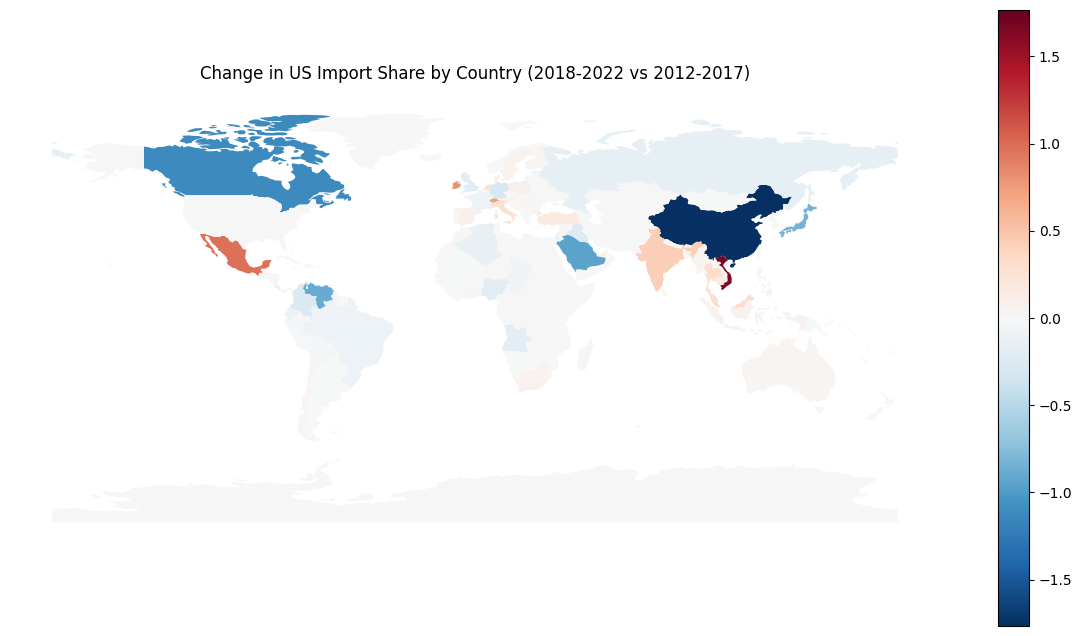

In [ ]:
US_import_share['Avg_Pre'] = US_import_share[pre_years].mean(axis=1)
US_import_share['Avg_Post'] = US_import_share[post_years].mean(axis=1)
US_import_share['Change'] = US_import_share['Avg_Post'] - US_import_share['Avg_Pre']

world_url = "https://raw.githubusercontent.com/datasets/geo-boundaries-world-110m/master/countries.geojson"
world = gpd.read_file(world_url)

world_merged = world.merge(US_import_share, left_on='name', right_on='Partner Name', how='left')
world_merged['Change_plot'] = world_merged['Change'].fillna(0)
max_val = world_merged['Change_plot'].abs().max()

fig, ax = plt.subplots(1, 1, figsize=(15, 8))
world_merged.plot(column='Change_plot', ax=ax, legend=True, cmap='RdBu_r', vmin=-max_val, vmax=max_val,
                  missing_kwds={'color': '#e0e0e0'})

ax.set_title('Change in US Import Share by Country (2018-2022 vs 2012-2017)', pad=10)
ax.set_axis_off()
plt.show()


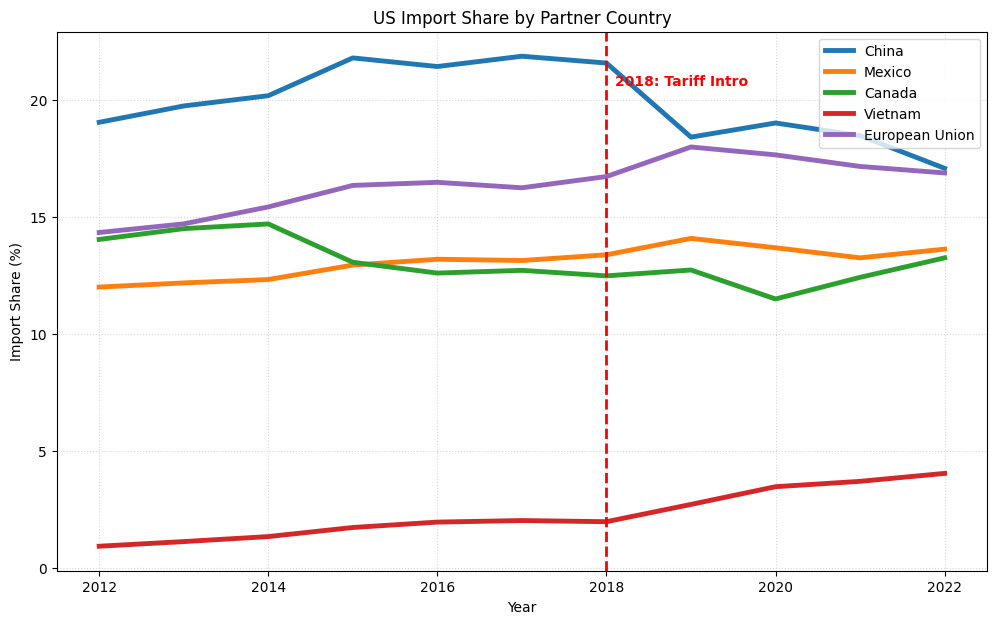

In [ ]:
eu_data = US_import_share[US_import_share['Partner Name'].isin(eu_members)]
eu_avg_pre = eu_data[pre_years].sum()
eu_avg_post = eu_data[post_years].sum()
eu_row = pd.DataFrame([['United States', 'European Union', 'Import', 'Import Partner Share (%)'] + eu_avg_pre.tolist() + eu_avg_post.tolist()],
                      columns=['Reporter Name','Partner Name','Trade Flow','Indicator'] + pre_years + post_years)
final_share = pd.concat([US_import_share, eu_row], ignore_index=True)

target_partners = ['China', 'Mexico', 'Canada', 'Vietnam', 'European Union']

plt.figure(figsize=(12,7))
for partner in target_partners:
    df = final_share[final_share['Partner Name']==partner]
    if not df.empty:
        plt.plot(range(2012,2023), df[pre_years+post_years].values.flatten(), label=partner, linewidth=3.5)
plt.axvline(2018, color='red', linestyle='--', linewidth=2)
plt.text(2018.1, plt.ylim()[1]*0.9,'2018: Tariff Intro', color='red', fontweight='bold')
plt.title('US Import Share by Partner Country')
plt.xlabel('Year'); plt.ylabel('Import Share (%)')
plt.legend(); plt.grid(True, linestyle=':', alpha=0.5); plt.show()

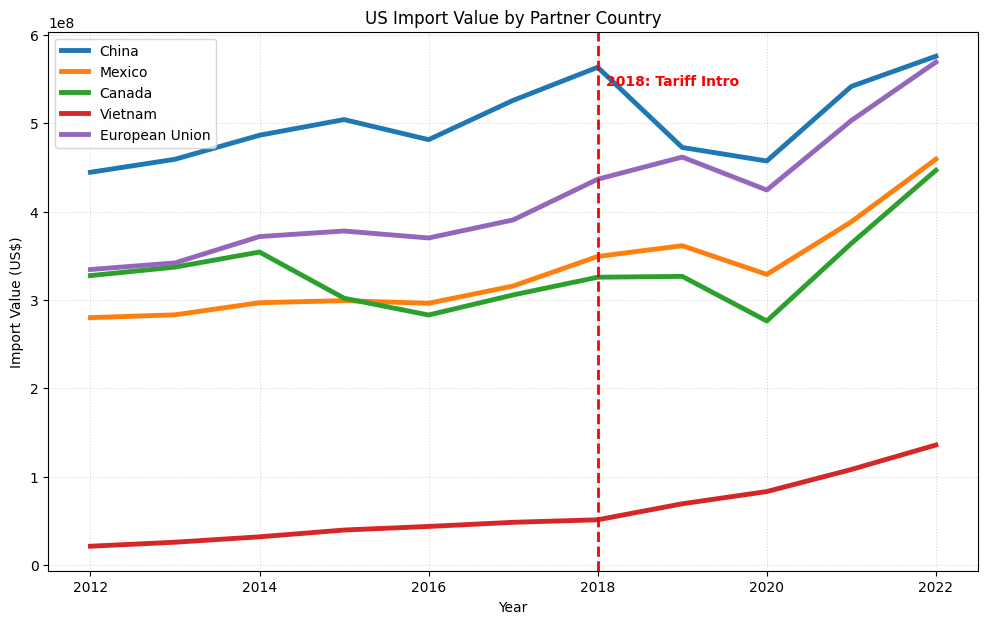

In [ ]:
# US import value by partner
eu_val_data = US_import_value[US_import_value['Partner Name'].isin(eu_members)]
eu_val_sum = eu_val_data[pre_years+post_years].sum()
eu_row_val = pd.DataFrame([['United States','European Union','Import','Import Value'] + eu_val_sum.tolist()],
                          columns=['Reporter Name','Partner Name','Trade Flow','Indicator'] + pre_years+post_years)
final_val = pd.concat([US_import_value, eu_row_val], ignore_index=True)

plt.figure(figsize=(12,7))
for partner in target_partners:
    df = final_val[final_val['Partner Name']==partner]
    if not df.empty:
        plt.plot(range(2012,2023), df[pre_years+post_years].values.flatten(), label=partner, linewidth=3.5)
plt.axvline(2018, color='red', linestyle='--', linewidth=2)
plt.text(2018.1, plt.ylim()[1]*0.9,'2018: Tariff Intro', color='red', fontweight='bold')
plt.title('US Import Value by Partner Country')
plt.xlabel('Year'); plt.ylabel('Import Value (US$)')
plt.legend(); plt.grid(True, linestyle=':', alpha=0.5); plt.show()

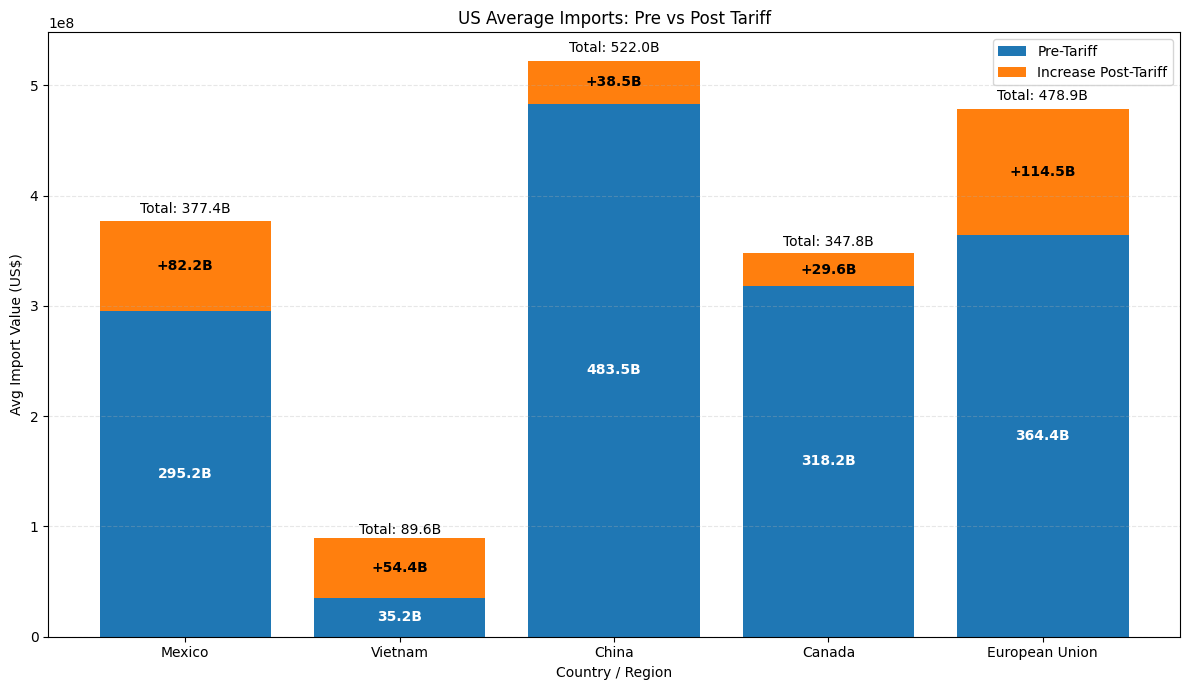

In [ ]:
# Difference-in-means (pre vs post)

results = []
others = ['Mexico','Vietnam','China','Canada']
for country in others:
    row = US_import_value[US_import_value['Partner Name']==country]
    if not row.empty:
        r = row.iloc[0]
        results.append({'Country':country,'AvgPre':r[pre_years].mean(),'AvgPost':r[post_years].mean()})
# EU aggregate
if not eu_val_data.empty:
    eu_totals = eu_val_data[pre_years+post_years].sum()
    results.append({'Country':'European Union','AvgPre':eu_totals[pre_years].mean(),'AvgPost':eu_totals[post_years].mean()})

plot_df = pd.DataFrame(results)
plot_df['Increase'] = plot_df['AvgPost'] - plot_df['AvgPre']
target_order = ['Mexico','Vietnam','China','Canada','European Union']
plot_df['Country'] = pd.Categorical(plot_df['Country'], categories=target_order, ordered=True)
plot_df = plot_df.sort_values('Country')

plt.figure(figsize=(12,7))
plt.bar(plot_df['Country'], plot_df['AvgPre'], color='#1f77b4', label='Pre-Tariff')
plt.bar(plot_df['Country'], plot_df['Increase'], bottom=plot_df['AvgPre'], color='#ff7f0e', label='Increase Post-Tariff')
for i,row in enumerate(plot_df.itertuples()):
    plt.text(i, row.AvgPre/2, f'{row.AvgPre/1e6:.1f}B', ha='center', va='center', color='white', fontweight='bold')
    plt.text(i, row.AvgPre + row.Increase/2, f'+{row.Increase/1e6:.1f}B', ha='center', va='center', color='black', fontweight='bold')
    plt.text(i, row.AvgPost + row.AvgPost*0.01, f'Total: {row.AvgPost/1e6:.1f}B', ha='center', va='bottom', fontsize=10)
plt.title('US Average Imports: Pre vs Post Tariff')
plt.ylabel('Avg Import Value (US$)')
plt.xlabel('Country / Region'); plt.legend(); plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout(); plt.show()

  Partner Name  Year   Share
0  Afghanistan  2012  0.0016
1      Albania  2012  0.0009
2      Algeria  2012  0.4369
3      Andorra  2012  0.0000
4       Angola  2012  0.4296


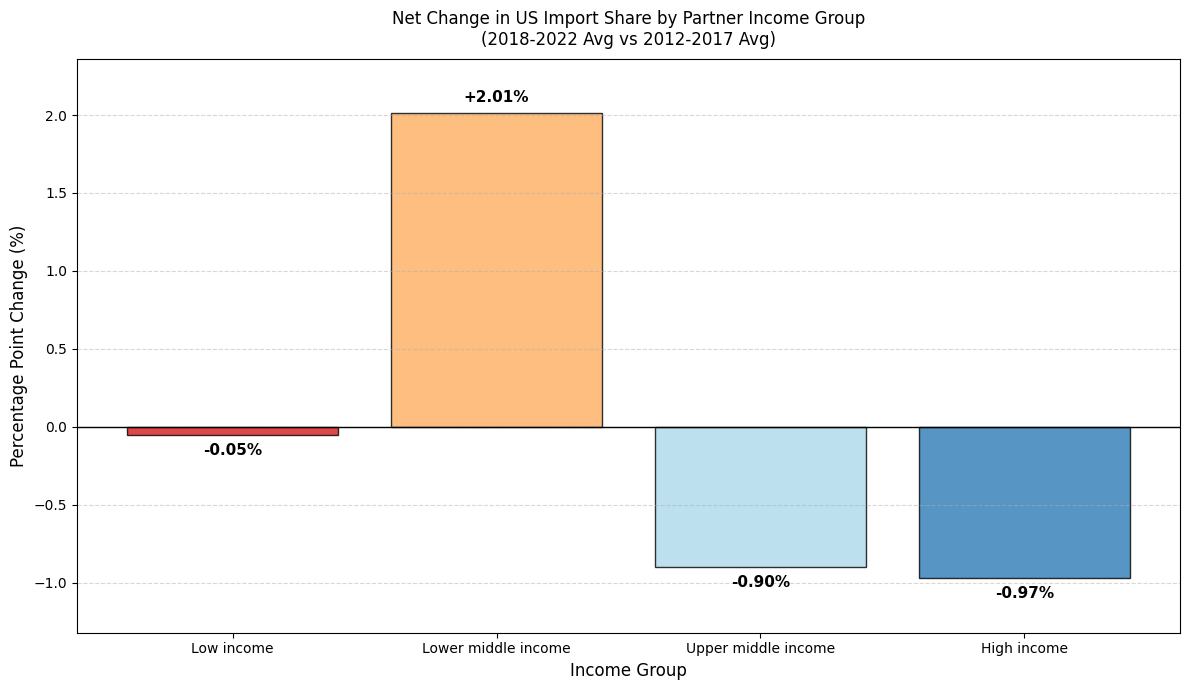

In [ ]:

meta = income_class[['TableName', 'IncomeGroup']].rename(columns={'TableName': 'Partner Name'})
meta['Partner Name'] = meta['Partner Name'].replace(name_corrections)

df_melted = US_import_share.melt(id_vars=['Partner Name'], value_vars=year_cols,
                                 var_name='Year', value_name='Share')
df_melted['Year'] = df_melted['Year'].astype(int)
print(df_melted.head(5))

df_income = df_melted.merge(meta, on='Partner Name', how='inner')

yearly_group_share = df_income.groupby(['IncomeGroup', 'Year'])['Share'].sum().reset_index()
yearly_group_share['Period'] = np.where(yearly_group_share['Year'] >= 2018, 'Post', 'Pre')
period_avg = yearly_group_share.groupby(['IncomeGroup', 'Period'])['Share'].mean().unstack()

order = ['Low income', 'Lower middle income', 'Upper middle income', 'High income']
period_avg = period_avg.reindex(order).dropna()
period_avg['Change'] = period_avg['Post'] - period_avg['Pre']

# Plot
plt.figure(figsize=(12, 7))
colors = ['#d7191c', '#fdae61', '#abd9e9', '#2c7bb6']
bars = plt.bar(period_avg.index, period_avg['Change'], color=colors, edgecolor='black', alpha=0.8)

plt.axhline(0, color='black', linewidth=1)
plt.title('Net Change in US Import Share by Partner Income Group\n(2018-2022 Avg vs 2012-2017 Avg)', pad=10)
plt.ylabel('Percentage Point Change (%)', fontsize=12)
plt.xlabel('Income Group', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    h = bar.get_height()
    va = 'bottom' if h > 0 else 'top'
    offset = 0.05 if h > 0 else -0.05
    plt.text(bar.get_x() + bar.get_width()/2, h + offset, f'{h:+.2f}%', ha='center', va=va, fontsize=11, fontweight='bold')

ymin, ymax = plt.ylim()
plt.ylim(ymin - 0.2, ymax + 0.2)

plt.tight_layout()
plt.show()


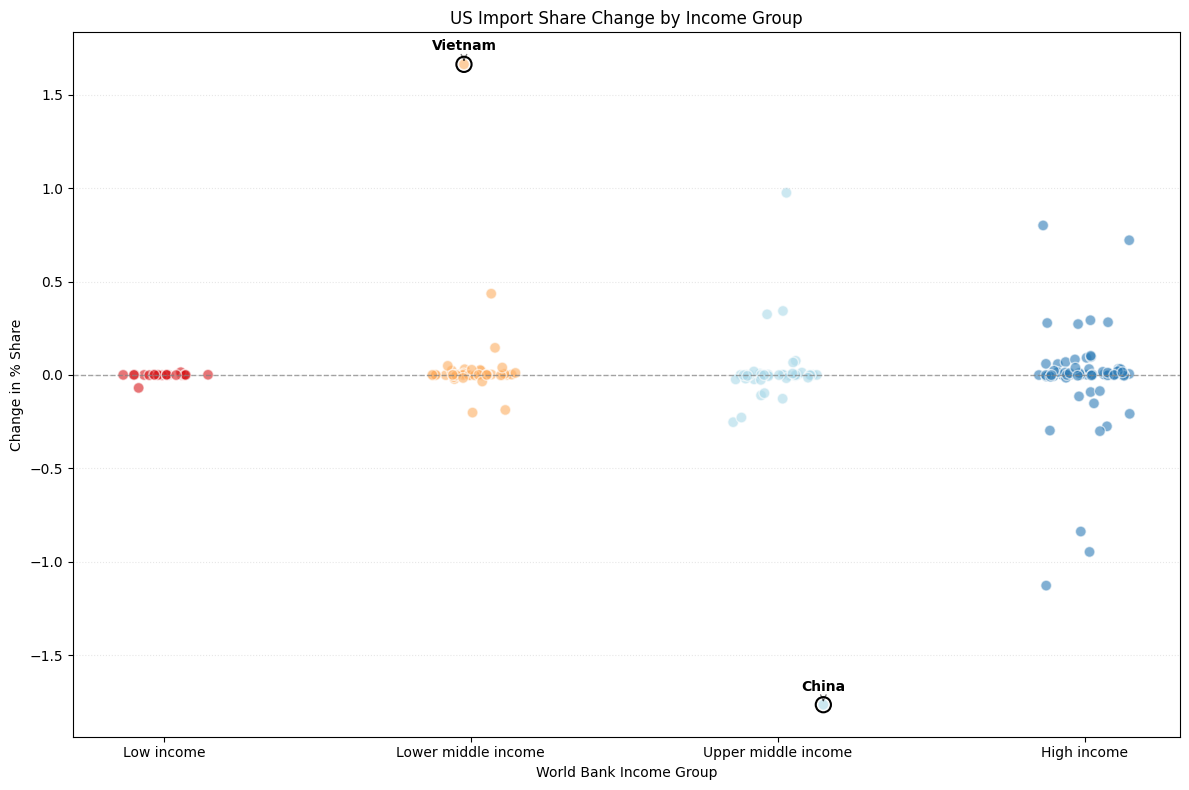

In [ ]:
# Change by Income Group
meta = income_class[['TableName','IncomeGroup']].rename(columns={'TableName':'Partner Name'})
meta['Partner Name'] = meta['Partner Name'].replace(name_corrections)
income_mapping = meta.set_index('Partner Name')['IncomeGroup'].to_dict()
US_import_share['Income_Group'] = US_import_share['Partner Name'].map(income_mapping)
scatter_df = US_import_share.dropna(subset=['Income_Group']).copy()
order = ['Low income','Lower middle income','Upper middle income','High income']
scatter_df['Income_Group_Cat'] = pd.Categorical(scatter_df['Income_Group'], categories=order, ordered=True)
scatter_df = scatter_df.sort_values('Income_Group_Cat')
group_to_num = {g:i for i,g in enumerate(order)}
scatter_df['X'] = scatter_df['Income_Group'].map(group_to_num)

plt.figure(figsize=(12,8))
np.random.seed(123)
x_jittered = scatter_df['X'] + np.random.uniform(-0.15,0.15,len(scatter_df))
colors = {'Low income':'#d7191c','Lower middle income':'#fdae61','Upper middle income':'#abd9e9','High income':'#2c7bb6'}
plt.scatter(x_jittered, scatter_df['Change'], color=scatter_df['Income_Group'].map(colors), alpha=0.6, edgecolors='w', s=60)
highlights = ['China','Vietnam']
for i,row in scatter_df.iterrows():
    if row['Partner Name'] in highlights:
        plt.annotate(row['Partner Name'], (x_jittered[i], row['Change']), xytext=(0,10), textcoords='offset points', ha='center', fontsize=10, fontweight='bold', arrowprops=dict(arrowstyle='->', color='black', alpha=0.5))
        plt.scatter(x_jittered[i], row['Change'], facecolors='none', edgecolors='black', s=120, linewidth=1.5)
plt.axhline(0, color='grey', linestyle='--', linewidth=1, alpha=0.7)
plt.xticks(range(len(order)), order); plt.title('US Import Share Change by Income Group')
plt.ylabel('Change in % Share'); plt.xlabel('World Bank Income Group'); plt.grid(axis='y', linestyle=':', alpha=0.3)
plt.tight_layout(); plt.show()

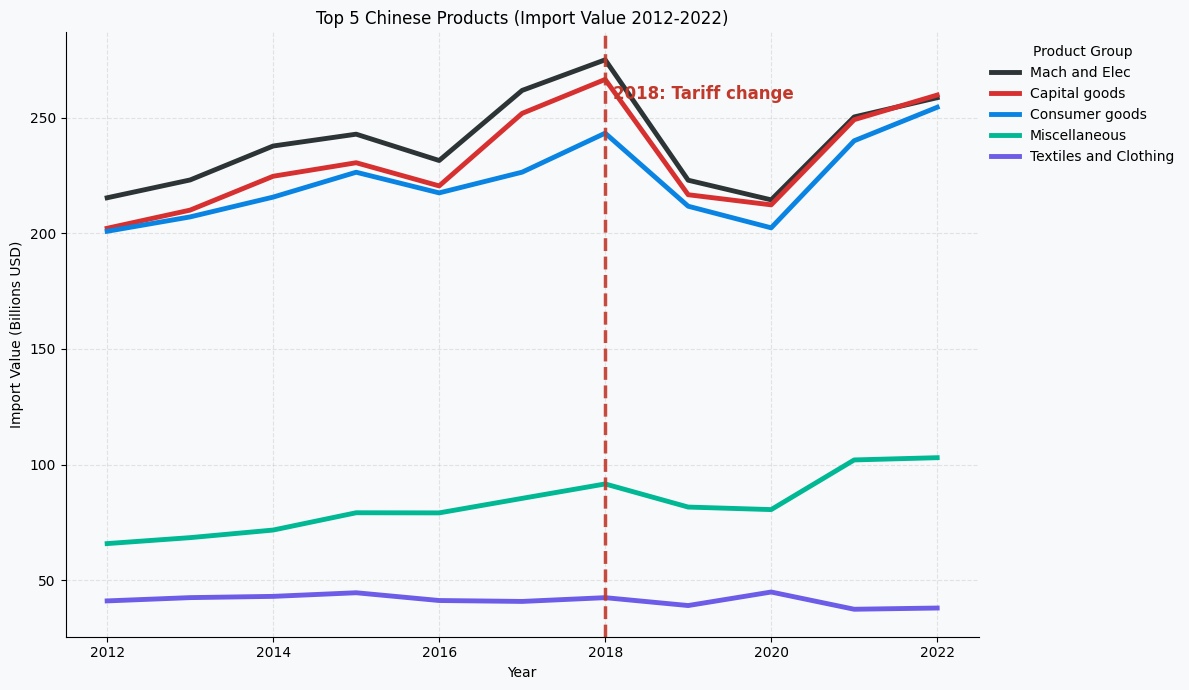

In [ ]:
#  Product-level: Top 5 Chinese sectors

year_cols = [str(y) for y in range(2012,2023)]
prod_China_val[year_cols] = prod_China_val[year_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
prod_China_sectors = prod_China_val[~prod_China_val['Product Group'].str.contains('All Product|Total|All Products', case=False, na=False)].copy()
prod_China_sectors['Total_Volume'] = prod_China_sectors[year_cols].sum(axis=1)
top_5_China = prod_China_sectors.nlargest(5, 'Total_Volume')

plt.figure(figsize=(12,7), facecolor='#f8f9fa'); ax=plt.axes(); ax.set_facecolor('#f8f9fa')
line_colors = ['#2d3436','#d63031','#0984e3','#00b894','#6c5ce7']
line_colors = ['#2d3436','#d63031','#0984e3','#00b894','#6c5ce7']

for idx, (_, row) in enumerate(top_5_China.iterrows()):
    plt.plot(
        [int(y) for y in year_cols],
        row[year_cols].values / 1e6,
        color=line_colors[idx],  # <-- use sequential idx, not DataFrame index
        label=row['Product Group'].strip(),
        linewidth=3.5
    )
plt.axvline(2018, color='#c0392b', linestyle='--', linewidth=2.5, alpha=0.9)
plt.text(2018.1, plt.ylim()[1]*0.9,'2018: Tariff change', color='#c0392b', fontweight='bold', fontsize=12)
plt.title('Top 5 Chinese Products (Import Value 2012-2022)')
plt.xlabel('Year'); plt.ylabel('Import Value (Billions USD)')
plt.legend(title='Product Group', loc='upper left', bbox_to_anchor=(1,1), fontsize=10, frameon=False)
plt.grid(True, linestyle='--', alpha=0.3); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

<Figure size 1200x800 with 0 Axes>

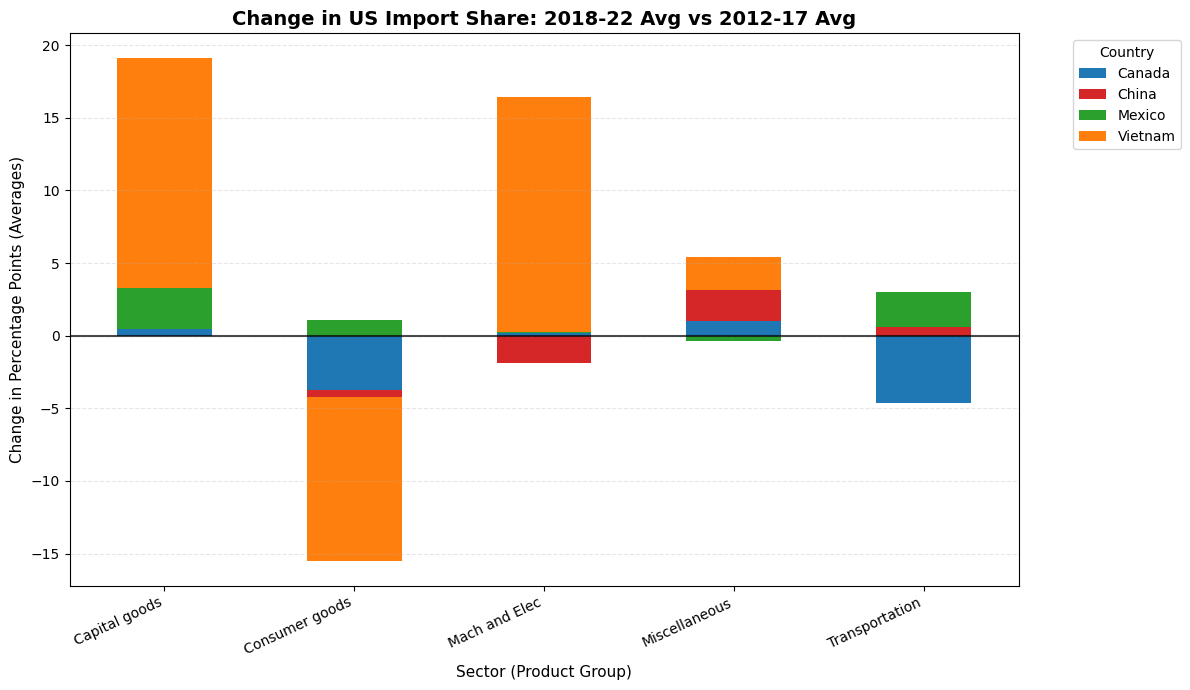

In [ ]:
#Imports share changes in USA from choosen 4countries on top5 sectors

# 1. Define the two periods
PRE_PERIOD = [str(y) for y in range(2012, 2018)]   # 2012-2017
POST_PERIOD = [str(y) for y in range(2018, 2023)]  # 2018-2022
SECTOR_COL = 'Product Group'

def get_average_change(data_var, country_label):
    # Clean column names
    temp = data_var.copy()
    temp.columns = [str(c).strip() for c in temp.columns]

    # Filter: Exclude 'All Products'
    if SECTOR_COL in temp.columns:
        temp = temp[temp[SECTOR_COL].str.strip() != 'All Products']

    # Ensure all year columns are numeric for averaging
    all_years = PRE_PERIOD + POST_PERIOD
    for y in all_years:
        temp[y] = pd.to_numeric(temp[y], errors='coerce')

    # Calculate Averages for both periods
    temp['Avg_Pre'] = temp[PRE_PERIOD].mean(axis=1)
    temp['Avg_Post'] = temp[POST_PERIOD].mean(axis=1)

    # The Change: Post-Tariff Average minus Pre-Tariff Average
    result = pd.DataFrame()
    result[SECTOR_COL] = temp[SECTOR_COL]
    result['Average Change'] = temp['Avg_Post'] - temp['Avg_Pre']
    result['Country'] = country_label
    result['Size_Ref'] = temp['Avg_Post'] # To rank Top 5 sectors

    return result

# 2. Process and combine the 4 countries
combined_averages = pd.concat([
    get_average_change(prod_CAN_share, 'Canada'),
    get_average_change(prod_CHN_share, 'China'),
    get_average_change(prod_MEX_share, 'Mexico'),
    get_average_change(prod_VIET_share, 'Vietnam')
])

# 3. Identify Top 5 Sectors based on average share in the Post-Tariff period
top_5_sectors = (combined_averages.groupby(SECTOR_COL)['Size_Ref']
                 .sum()
                 .nlargest(5)
                 .index)

plot_data = combined_averages[combined_averages[SECTOR_COL].isin(top_5_sectors)]

# 4. Create the Pivot Table for the Stacked Bar Chart
final_pivot = plot_data.pivot(index=SECTOR_COL, columns='Country', values='Average Change')

# 5. Visualization
colors = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e'] # Canada, China, Mexico, Vietnam

plt.figure(figsize=(12, 8))
ax = final_pivot.plot(kind='bar', stacked=True, figsize=(12, 7), color=colors)

# Chart labels and styling
plt.axhline(0, color='black', linewidth=1.5, alpha=0.7)
plt.title('Change in US Import Share: 2018-22 Avg vs 2012-17 Avg', fontsize=14, fontweight='bold')
plt.ylabel('Change in Percentage Points (Averages)', fontsize=11)
plt.xlabel('Sector (Product Group)', fontsize=11)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=25, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

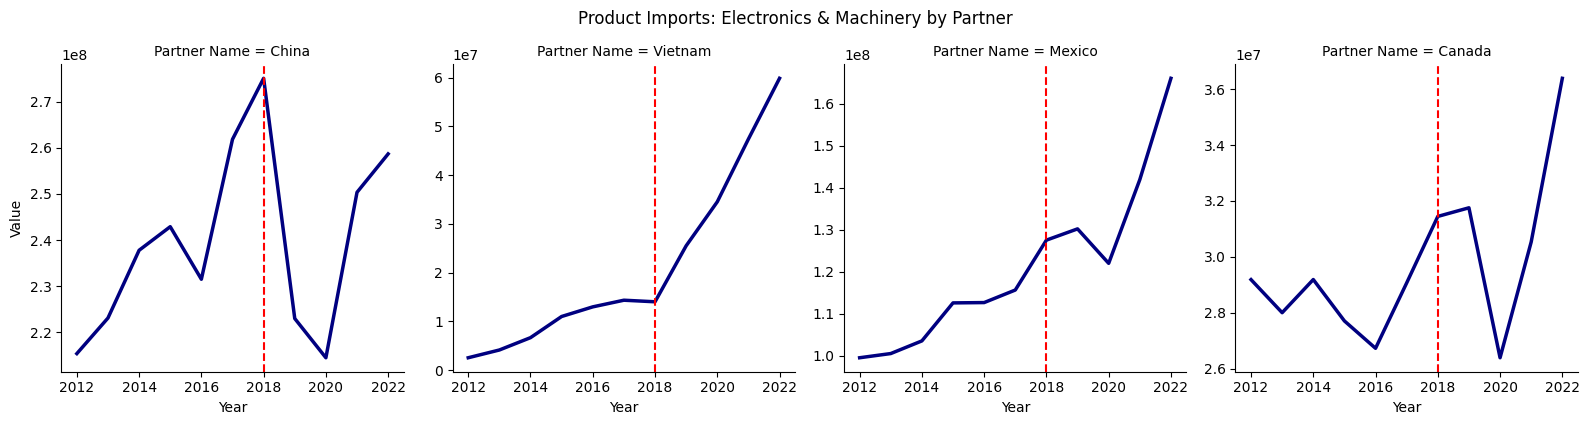

In [ ]:
#  Alternative suppliers (small multiples by country)

prod_list = [('China', prod_China_val), ('Vietnam', prod_Vietnam_val),
             ('Mexico', prod_Mexico_val), ('Canada', prod_Canada_val)]
prod_data = []

for c_name, df_prod in prod_list:
    id_vars = [col for col in df_prod.columns if col not in year_cols]
    tmp = df_prod.melt(id_vars=id_vars, value_vars=year_cols,
                       var_name='Year', value_name='Value')
    tmp['Year'] = tmp['Year'].astype(int)
    tmp['Value'] = pd.to_numeric(tmp['Value'], errors='coerce').fillna(0)
    tmp = tmp[~tmp['Product Group'].str.contains('All Product|Total|All Products', case=False, na=False)]
    tmp['Partner Name'] = c_name
    prod_data.append(tmp)

df_products = pd.concat(prod_data)
# Filter Electronics/Machinery
df_elec = df_products[df_products['Product Group']=='Mach and Elec']

g = sns.FacetGrid(df_elec, col='Partner Name', sharey=False, height=4)
g.map(sns.lineplot, 'Year', 'Value', color='navy', linewidth=2.5)
for ax in g.axes.flat:
    ax.axvline(2018, color='red', linestyle='--')
g.fig.suptitle('Product Imports: Electronics & Machinery by Partner', y=1.05)
plt.show()

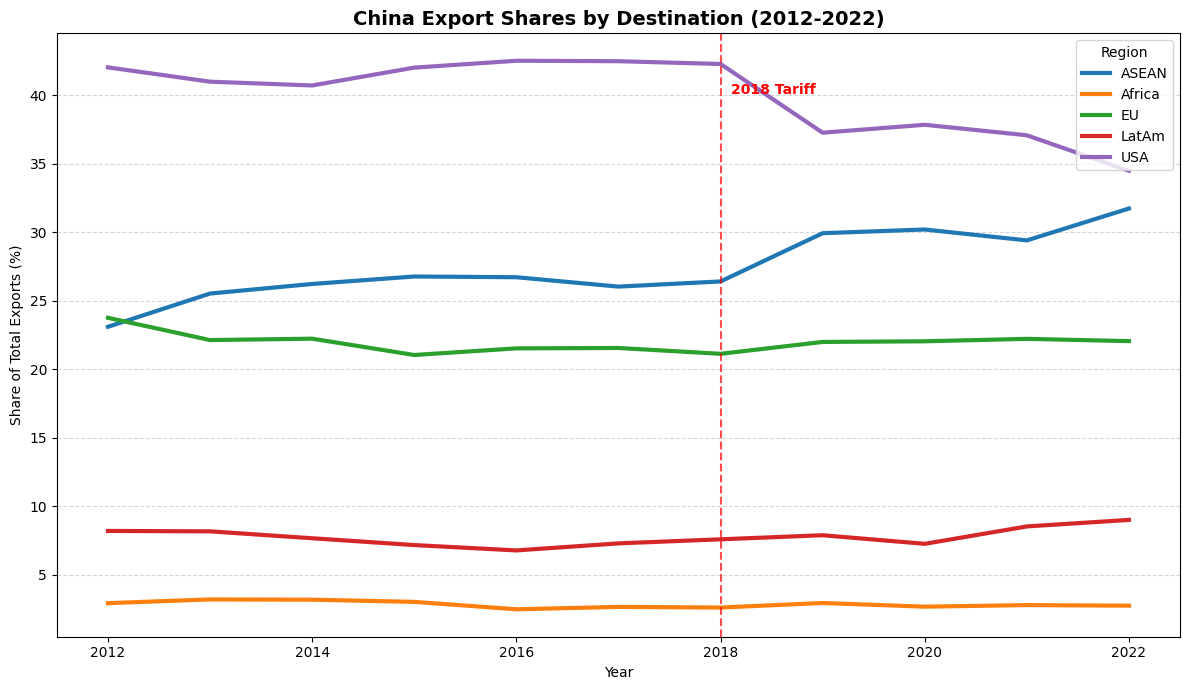

In [ ]:
# Assign regions to each country
CHN_export_value['Region'] = CHN_export_value['Partner Name'].map(region_map)

# Aggregate exports by region
region_exports = CHN_export_value.groupby('Region')[year_cols].sum()

# Calculate export shares
region_shares = region_exports.div(region_exports.sum(axis=0), axis=1) * 100  # convert to %

# Plot
plt.figure(figsize=(12, 7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, region in enumerate(region_shares.index):
    plt.plot([int(y) for y in year_cols],
             region_shares.loc[region].values,
             color=colors[i % len(colors)],
             label=region,
             linewidth=3)

plt.title("China Export Shares by Destination (2012-2022)", fontsize=14, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Share of Total Exports (%)")
plt.axvline(2018, color='red', linestyle='--', alpha=0.7)
plt.text(2018.1, plt.ylim()[1]*0.9, "2018 Tariff", color='red', fontweight='bold')
plt.legend(title="Region")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


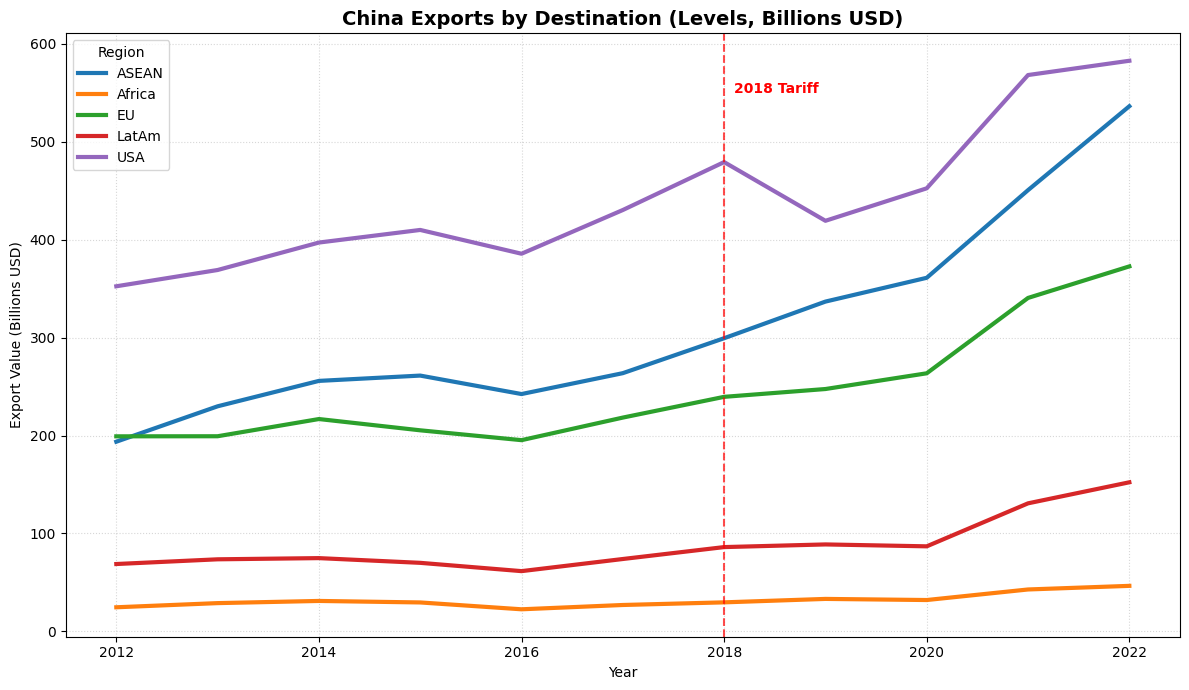

In [ ]:
# Aggregate exports by region
region_exports = CHN_export_value.groupby('Region')[year_cols].sum() / 1e6  # scale to billions

# Plot absolute export levels
plt.figure(figsize=(12,7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, region in enumerate(region_exports.index):
    plt.plot([int(y) for y in year_cols],
             region_exports.loc[region].values,
             label=region,
             linewidth=3,
             color=colors[i % len(colors)])

plt.axvline(2018, color='red', linestyle='--', alpha=0.7)
plt.text(2018.1, plt.ylim()[1]*0.9, "2018 Tariff", color='red', fontweight='bold')

plt.title('China Exports by Destination (Levels, Billions USD)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Export Value (Billions USD)')
plt.legend(title='Region')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# 3. Process Data
stats = CHN_export_share.copy()
stats.columns = [str(c).strip() for c in stats.columns]
stats['Region'] = stats['Partner Name'].str.strip().map(region_map)

# Filter for mapped regions and ensure numeric
stats = stats.dropna(subset=['Region'])
for y in pre_yrs + post_yrs:
    stats[y] = pd.to_numeric(stats[y], errors='coerce')

# 4. Calculate Regional Averages
results = stats.groupby('Region')[pre_yrs + post_yrs].mean()
results['Pre_Avg'] = results[pre_yrs].mean(axis=1)
results['Post_Avg'] = results[post_yrs].mean(axis=1)
results['Net_Change'] = results['Post_Avg'] - results['Pre_Avg']

# 5. Print Summary Table
print("--- 5-Region Strategic Summary ---")
print(results[['Pre_Avg', 'Post_Avg', 'Net_Change']].round(2))

# 6. Plotting the Comparison (Overlaid Bar)
plt.figure(figsize=(10, 6))
plt.bar(results.index, results['Pre_Avg'], width=0.6, label='2012-17 Avg', color='lightgrey')
colors = ['red' if post < pre else 'green' for pre, post in zip(results['Pre_Avg'], results['Post_Avg'])]
plt.bar(results.index, results['Post_Avg'], width=0.3, label='2018-22 Avg', color=colors)

plt.title('China Export Share Shift: USA vs. Other Regions', fontweight='bold')
plt.ylabel('Market Share (%)')
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'pre_yrs' is not defined